In [1]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.5 MB/s eta 0:00:00


In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

In [6]:
%reload_ext watermark
%watermark -a "Eduardo Lyrio"

Author: Eduardo Lyrio



## **Carregando e compreendendo o conjunto de dados**

In [7]:
# Carrega o dataset
df_dsa = pd.read_csv("dataset.csv")

In [8]:
# Shape
df_dsa.shape

(500, 8)

In [9]:
# Visusaliza as 5 primeiras linhas
df_dsa.head()

,ID Mouse,Medicamento,Sexo,Idade_Meses,Peso (g),Timepoint,Tumor Volume (mm3),Sitios Metastáticos
0,m000,Placebo,Masculino,18,21,0,45.780350,2
1,m000,Ramicane,Masculino,24,17,5,42.728114,0
2,m000,Ramicane,Feminino,19,23,10,40.827502,1
3,m000,Capomulin,Feminino,21,23,15,38.578206,2
4,m000,Infubinol,Masculino,12,17,20,35.094393,2


Tipos de Medicamento:

Placebo: Um placebo é uma substância sem qualquer efeito terapêutico, usada como controle em experimentos. Ao administrar um placebo a um grupo de camundongos, os pesquisadores podem estabelecer uma linha de base para comparar os efeitos dos medicamentos reais. Isso ajuda a determinar se as mudanças observadas nos grupos tratados são devido ao medicamento em teste ou outros fatores externos.

Ramicane e Capomulin: São exemplos de medicamentos reais usados frequentemente em estudos para tratar ou controlar o crescimento de tumores. Esses medicamentos podem ter mecanismos de ação específicos, como inibir o crescimento de células cancerígenas ou reduzir a inflamação que promove o crescimento do tumor.

Infubinol: Outro tipo de medicamento que pode ser usado em estudos para avaliar sua eficácia na prevenção ou redução do crescimento de tumores em camundongos. Como os demais, sua inclusão no estudo visa testar sua eficácia e potenciais efeitos colaterais.




In [10]:
# Info
df_dsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID Mouse             500 non-null    object 
 1   Medicamento          500 non-null    object 
 2   Sexo                 500 non-null    object 
 3   Idade_Meses          500 non-null    int64  
 4   Peso (g)             500 non-null    int64  
 5   Timepoint            500 non-null    int64  
 6   Tumor Volume (mm3)   500 non-null    float64
 7   Sitios Metastáticos  500 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 31.4+ KB


# Limpeza Inicial dos Dados

In [11]:
# Nomes das colunas
df_dsa.columns

Index(['ID Mouse', 'Medicamento', 'Sexo', 'Idade_Meses', 'Peso (g)',
       'Timepoint', 'Tumor Volume (mm3)', 'Sitios Metastáticos'],
      dtype='object')

In [15]:
# Valores unicos para id do mouse
df_dsa['ID Mouse'].nunique()

100

In [16]:
# Verificar valores ausentes
df_dsa.isna().any()

,0
ID Mouse,False
Medicamento,False
Sexo,False
Idade_Meses,False
Peso (g),False
Timepoint,False
Tumor Volume (mm3),False
Sitios Metastáticos,False


In [19]:
# Extrai duplicatas na combinação "ID Mouse" e "Timepoint" (se houver)
duplicate_ID = df_dsa.loc[df_dsa.duplicated(subset = ['ID Mouse', 'Timepoint']), 'ID Mouse'].unique()

In [20]:
# Se houver duplicata, removemos
df_dsa_final = df_dsa[df_dsa['ID Mouse'].isin(duplicate_ID) == False]

In [21]:
#Shape
df_dsa_final.shape

(500, 8)

In [22]:
# Visualizar as 5 primeiras linhas
df_dsa_final.head()

,ID Mouse,Medicamento,Sexo,Idade_Meses,Peso (g),Timepoint,Tumor Volume (mm3),Sitios Metastáticos
0,m000,Placebo,Masculino,18,21,0,45.780350,2
1,m000,Ramicane,Masculino,24,17,5,42.728114,0
2,m000,Ramicane,Feminino,19,23,10,40.827502,1
3,m000,Capomulin,Feminino,21,23,15,38.578206,2
4,m000,Infubinol,Masculino,12,17,20,35.094393,2


# **Sumário Estastístico**

In [23]:
# Nome das colunas
df_dsa_final.columns

Index(['ID Mouse', 'Medicamento', 'Sexo', 'Idade_Meses', 'Peso (g)',
       'Timepoint', 'Tumor Volume (mm3)', 'Sitios Metastáticos'],
      dtype='object')

In [24]:
# Agrupamento pelo Medicamento e filtro pela varíavel "Tumpr volume (mm3)"
df_dsa_final_agrupado = df_dsa_final.groupby("Medicamento")["Tumor Volume (mm3)"]

In [25]:
# Agora calculamos as estatísticas da variável "Tumor Volume (mm3)"
media = df_dsa_final_agrupado.mean()
mediana = df_dsa_final_agrupado.median()
variancia = df_dsa_final_agrupado.var()
desvio_padrao = df_dsa_final_agrupado.std()
sem = df_dsa_final_agrupado.sem()

In [26]:
# Cria o dataframe de sumário
df_sumario_estatistico = pd.DataFrame({'Média': media,
                                       'Mediana': mediana,
                                       'Variância': variancia,
                                       'Desvio Padrão': desvio_padrao,
                                       'SEM': sem})

In [27]:
df_sumario_estatistico

,Média,Mediana,Variância,Desvio Padrão,SEM
Medicamento,,,,,
Capomulin,39.952874,40.162141,19.485353,4.414222,0.396409
Infubinol,39.527638,39.598429,22.306899,4.723018,0.436643
Placebo,40.204385,40.072851,22.427712,4.735790,0.421898
Ramicane,40.437902,40.682981,16.588849,4.072941,0.353169


In [28]:
# Esta seria uma alternativa para agrupamento e cálculo das estatísticas
sumario_agregado = df_dsa_final_agrupado.agg(["mean", "median", "var", "std", "sem"])

As funções usadas aqui são:

mean: Calcula a média aritmética dos dados.
median: Determina o valor mediano dos dados.
var: Calcula a variância dos dados, uma medida de dispersão que mostra quão distantes os valores estão da média.
std: Determina o desvio padrão, que é a raiz quadrada da variância e fornece uma medida de quão espalhados estão os valores em relação à média.
sem: Calcula o erro padrão da média (standard error of the mean), que indica a precisão da média como uma estimativa da média populacional.

In [29]:
sumario_agregado

,mean,median,var,std,sem
Medicamento,,,,,
Capomulin,39.952874,40.162141,19.485353,4.414222,0.396409
Infubinol,39.527638,39.598429,22.306899,4.723018,0.436643
Placebo,40.204385,40.072851,22.427712,4.735790,0.421898
Ramicane,40.437902,40.682981,16.588849,4.072941,0.353169


# Análise Exploratória

In [30]:
# Nomes das colunas
df_dsa_final.columns

Index(['ID Mouse', 'Medicamento', 'Sexo', 'Idade_Meses', 'Peso (g)',
       'Timepoint', 'Tumor Volume (mm3)', 'Sitios Metastáticos'],
      dtype='object')

In [31]:
# Registros por medicamentos
df_dsa_final ['Medicamento']. value_counts()

,count
Medicamento,
Ramicane,133
Placebo,126
Capomulin,124
Infubinol,117


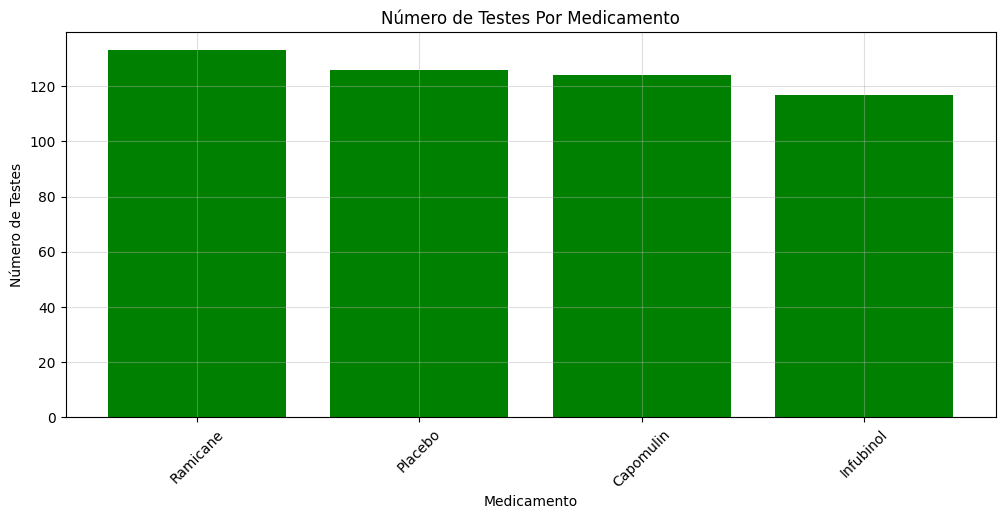

In [32]:
# Número de testes por medicamento

#Plot
plt.figure(figsize = (12, 5))
x_axis = df_dsa_final["Medicamento"].value_counts().index.values
y_axis = df_dsa_final["Medicamento"].value_counts().values
plt.bar(x_axis, y_axis, color = "green")
plt.title("Número de Testes Por Medicamento")
plt.xlabel("Medicamento")
plt.ylabel("Número de Testes")
plt.grid(alpha = 0.4)
plt.xticks(rotation = 45)
plt.show()

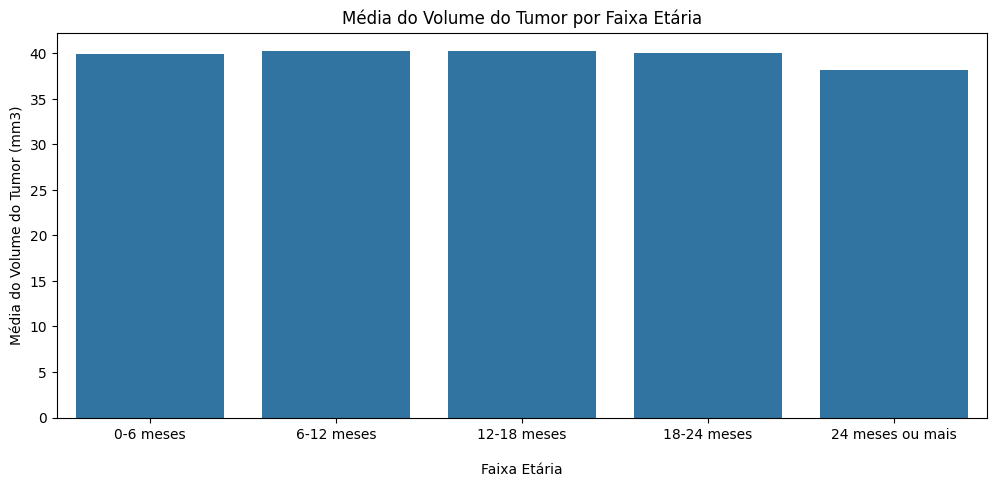

In [33]:
# Média do Volume do Tumor por Faixa Etária

# Definindo faixas etárias
bins = [0, 6, 12, 18, 24, 30]
labels = ['0-6 meses', '6-12 meses', '12-18 meses', '18-24 meses', '24 meses ou mais']

# Divide as faixas
df_dsa_final['faixa_etaria'] = pd.cut(df_dsa_final['Idade_Meses'],
                                      bins = bins,
                                      labels = labels,
                                      right = False)

# Agrupando por 'faixa_etaria' e calculando a média do 'Tumor Volume (mm3)'
media_tumor = df_dsa_final.groupby('faixa_etaria')['Tumor Volume (mm3)'].mean().reset_index()

# Criando o gráfico
import seaborn as sns
plt.figure(figsize = (12, 5))
sns.barplot(x = 'faixa_etaria', y = 'Tumor Volume (mm3)', data = media_tumor)
plt.title('Média do Volume do Tumor por Faixa Etária')
plt.xlabel('\nFaixa Etária')
plt.ylabel('Média do Volume do Tumor (mm3)')
plt.show()

Quartis, Outliers e Boxplots
Quartis são valores que dividem um conjunto de dados em quatro partes iguais. O primeiro quartil (Q1) é o valor que separa os 25% menores dados dos demais, o segundo quartil (Q2) ou mediana divide os dados ao meio, e o terceiro quartil (Q3) separa os 75% menores dados dos 25% maiores.

Outliers ou valores atípicos são observações que se distanciam significativamente dos outros dados do conjunto. Eles podem ser resultado de variabilidade nos dados ou de erros de medição. São importantes porque podem distorcer estatísticas e proporcionar insights sobre anomalias.

Um boxplot é um método gráfico para representar a distribuição de dados numéricos por meio de quartis. Ele mostra o mínimo, o primeiro quartil (Q1), a mediana (Q2), o terceiro quartil (Q3) e o máximo, com linhas (chamadas de "bigodes" ou whiskers) que se estendem para mostrar a variabilidade fora dos quartis. Outliers são frequentemente indicados como pontos individuais que ficam fora dos "bigodes".